# Credit Risk Default Prediction

## Introduction
A bank has to decide whether to approve a credit card application, and the main risk is that the borrower will not repay. \
This project uses 10 borrower variables (age, income, debt ratio, credit utilization, past-due history, and others) to predict whether a borrower is likely to default, so the bank can decide who should be approved.


## 0. Setup

In [125]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_auc_score, roc_curve)


## 1. Load Data

The raw dataset is **cs-train.csv** from the Kaggle [Give Me Some Credit competition](https://www.kaggle.com/competitions/GiveMeSomeCredit/overview).

In [126]:
df = pd.read_csv("cs-training.csv", index_col=0)
print("Data shape:", df.shape)
df.head()


Data shape: (150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## 2. Exploratory Data Analysis

| Variable | Description | Type | EDA finding & treatment |
|---|---|---|---|
| `SeriousDlqin2yrs` | **Target.** 1 if the borrower became 90+ days past due within two years, 0 otherwise | Binary (0/1) | default rate 6.59% after cleaning |
| `RevolvingUtilizationOfUnsecuredLines` | Ratio of the total amount of money owed to total credit limit | Ratio | Extreme values far above 1 - 371 rows above 2 capped at 2 |
| `age` | Age of the borrower in years | Integer | Found 1 borrower with age = 0, which is not a valid value for a credit applicant, removed all observations with age < 21 |
| `NumberOfTime30-59DaysPastDueNotWorse` | Number of times the borrower was 30-59 days past due (but no worse) in the last 2 years | Integer | Contains 96 and 98, which look like placeholder codes, not real counts, removed observations with these values |
| `DebtRatio` | Monthly debt payments, alimony, and living costs divided by monthly gross income | Ratio | Extreme values; 29646 rows above 5 capped at 5 |
| `MonthlyIncome` | Monthly income | Continuous | About 19.8% missing values, replaced with median |
| `NumberOfOpenCreditLinesAndLoans` | Number of open loans (installment, e.g. car loan or mortgage) and lines of credit (e.g. credit cards) | Integer | No cleaning needed |
| `NumberOfTimes90DaysLate` | Number of times the borrower was 90+ days past due | Integer | Same 96 / 98 codes; removed observations with these values |
| `NumberRealEstateLoansOrLines` | Number of mortgage and real estate loans, including home equity lines of credit | Integer | No cleaning needed |
| `NumberOfTime60-89DaysPastDueNotWorse` | Number of times the borrower was 60-89 days past due (but no worse) in the last 2 years | Integer | Same 96 / 98 codes; removed observations with these values |
| `NumberOfDependents` | Number of dependents in the family, excluding the borrower | Integer | About 2.6% missing, replaced with the median |


In [127]:
print("Null Values and Proportions")
null_val_sums = df.isnull().sum()
pd.DataFrame({"Column": null_val_sums.index, "Number of Null Values": null_val_sums.values,
             "Proportion": null_val_sums.values / len(df) })

Null Values and Proportions


,Column,Number of Null Values,Proportion
0,SeriousDlqin2yrs,0,0.000000
1,RevolvingUtilizationOfUnsecuredLines,0,0.000000
2,age,0,0.000000
3,NumberOfTime30-59DaysPastDueNotWorse,0,0.000000
4,DebtRatio,0,0.000000
5,MonthlyIncome,29731,0.198207
6,NumberOfOpenCreditLinesAndLoans,0,0.000000
7,NumberOfTimes90DaysLate,0,0.000000
8,NumberRealEstateLoansOrLines,0,0.000000
9,NumberOfTime60-89DaysPastDueNotWorse,0,0.000000


In [128]:
#replace the null values with median
df["MonthlyIncome"] = df["MonthlyIncome"].fillna(df["MonthlyIncome"].median())
df["NumberOfDependents"] = df["NumberOfDependents"].fillna(df["NumberOfDependents"].median())

In [129]:
# summary statistics for all variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,150000.0,6418.454920,12890.395542,0.0,3903.000000,5400.000000,7400.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


Text(0.5, 1.0, 'Distribution of Borrower Age')

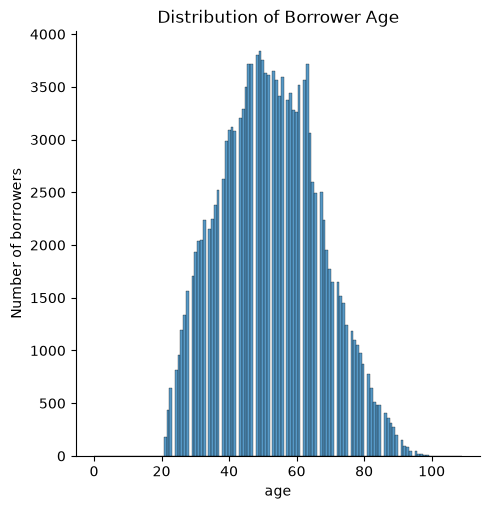

In [130]:
sns.displot(df.age)
plt.ylabel("Number of borrowers")
plt.title("Distribution of Borrower Age")

In [131]:
df.loc[df['age'] <21]

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
65696,0,1.0,0,1,0.436927,6000.0,6,0,2,0,2.0


In [132]:
df = df[df["age"] >= 21] #keep the data that age>=21

One borrower has an age below 21 (age = 0), which is not a valid value for a credit applicant, so this observation was removed as a data entry error.

In [133]:
# cap RevolvingUtilizationOfUnsecuredLines at 2
n_capped = (df["RevolvingUtilizationOfUnsecuredLines"] > 2).sum()
print(f"{n_capped} rows have utilization > 2 ({n_capped/len(df):.2%} of data); capping at 2")
df["RevolvingUtilizationOfUnsecuredLines"] = df["RevolvingUtilizationOfUnsecuredLines"].clip(upper=2)

371 rows have utilization > 2 (0.25% of data); capping at 2


In [134]:
late_pay_cols = ["NumberOfTimes90DaysLate", "NumberOfTime60-89DaysPastDueNotWorse",
                "NumberOfTime30-59DaysPastDueNotWorse"]
df["NumberOfTimes90DaysLate"].value_counts().sort_index()

NumberOfTimes90DaysLate
0     141661
1       5243
2       1555
3        667
4        291
5        131
6         80
7         38
8         21
9         19
10         8
11         5
12         2
13         4
14         2
15         2
17         1
96         5
98       264
Name: count, dtype: int64

In [135]:
df["NumberOfTime60-89DaysPastDueNotWorse"].value_counts().sort_index()

NumberOfTime60-89DaysPastDueNotWorse
0     142395
1       5731
2       1118
3        318
4        105
5         34
6         16
7          9
8          2
9          1
11         1
96         5
98       264
Name: count, dtype: int64

In [136]:
df["NumberOfTime30-59DaysPastDueNotWorse"].value_counts().sort_index()

NumberOfTime30-59DaysPastDueNotWorse
0     126018
1      16032
2       4598
3       1754
4        747
5        342
6        140
7         54
8         25
9         12
10         4
11         1
12         2
13         1
96         5
98       264
Name: count, dtype: int64

In [137]:
#remove placeholder codes (96/98) in the past-due columns
late_cols = ["NumberOfTime30-59DaysPastDueNotWorse",
             "NumberOfTime60-89DaysPastDueNotWorse",
             "NumberOfTimes90DaysLate"]

bad_rows = (df[late_cols] >= 96).any(axis=1)
print(f"{bad_rows.sum()} rows removed for placeholder codes ({bad_rows.mean():.2%} of data)")


269 rows removed for placeholder codes (0.18% of data)


In [138]:
# cap DebtRatio at 5
n_capped = (df["DebtRatio"] > 5).sum()
print(f"{n_capped} rows have DebtRatio > 5 ({n_capped/len(df):.2%} of data); capping at 5")
df["DebtRatio"] = df["DebtRatio"].clip(upper=5)

29646 rows have DebtRatio > 5 (19.76% of data); capping at 5


In [139]:
print("Default rate before removal:", df["SeriousDlqin2yrs"].mean())
df = df[~bad_rows]
print("Default rate after removal:", df["SeriousDlqin2yrs"].mean())

Default rate before removal: 0.06684044560297069
Default rate after removal: 0.06597876177118814


In [140]:
print("Pearson correlation of each feature with default:")
df.corr(numeric_only=True)["SeriousDlqin2yrs"].sort_values(ascending=False)

Pearson correlation of each feature with default:


SeriousDlqin2yrs                        1.000000
NumberOfTimes90DaysLate                 0.314535
RevolvingUtilizationOfUnsecuredLines    0.277101
NumberOfTime30-59DaysPastDueNotWorse    0.274553
NumberOfTime60-89DaysPastDueNotWorse    0.268130
NumberOfDependents                      0.048320
NumberRealEstateLoansOrLines           -0.003957
DebtRatio                              -0.012856
MonthlyIncome                          -0.016531
NumberOfOpenCreditLinesAndLoans        -0.024232
age                                    -0.112979
Name: SeriousDlqin2yrs, dtype: float64

The features most correlated with default are all related to past delinquency history and evolving credit utilization, suggesting that past repayment behavior is the strongest predictive signal.

## 3. Train/Test Split and Scaling

In [141]:
X = df.drop(columns=["SeriousDlqin2yrs"])
y = df["SeriousDlqin2yrs"]

# first split off the test set (20%), untouched until final reporting
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# then split the remaining 80% into train (60% of total) and validation (20% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full
)  # 0.25 * 0.80 = 0.20

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit scaler on train only
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Train set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)


Train set: (89838, 10)
Validation set: (29946, 10)
Test set: (29946, 10)


## 4. Model Training

Since defaults make up only 6.59% of the data, `class_weight="balanced"` is used to address class imbalance.

In [142]:
# create model for logistic method
logreg = LogisticRegression(max_iter=1000, class_weight="balanced")
logreg.fit(X_train_scaled, y_train)
y_pred_log = logreg.predict(X_test_scaled)
y_proba_log = logreg.predict_proba(X_test_scaled)[:, 1]
y_proba_val = logreg.predict_proba(X_val_scaled)[:, 1]

# create model for decision tree
tree = DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)
y_proba_tree = tree.predict_proba(X_test)[:, 1]


## 5. Model Evaluation

In [143]:
def report(name, y_true, y_pred, y_proba):
    print("=" * 60)
    print(f"Model: {name}")
    print("=" * 60)
    print(classification_report(y_true, y_pred, digits=3))
    auc = roc_auc_score(y_true, y_proba)
    print(f"AUC: {auc:.4f}")
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"Confusion matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")
    return cm, auc

cm_log, auc_log = report("Logistic Regression (balanced)", y_test, y_pred_log, y_proba_log)
cm_tree, auc_tree = report("Decision Tree (max_depth=6, balanced)", y_test, y_pred_tree, y_proba_tree)

Model: Logistic Regression (balanced)
              precision    recall  f1-score   support

           0      0.977     0.811     0.886     27970
           1      0.213     0.724     0.329      1976

    accuracy                          0.806     29946
   macro avg      0.595     0.768     0.608     29946
weighted avg      0.926     0.806     0.850     29946

AUC: 0.8480
Confusion matrix: TN=22695, FP=5275, FN=546, TP=1430
Model: Decision Tree (max_depth=6, balanced)
              precision    recall  f1-score   support

           0      0.974     0.821     0.891     27970
           1      0.214     0.692     0.327      1976

    accuracy                          0.812     29946
   macro avg      0.594     0.756     0.609     29946
weighted avg      0.924     0.812     0.854     29946

AUC: 0.8362
Confusion matrix: TN=22953, FP=5017, FN=608, TP=1368


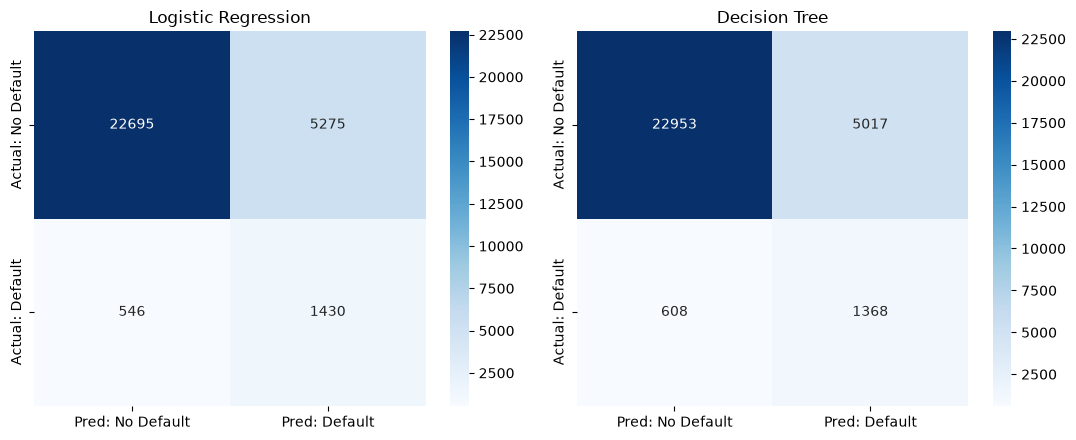

In [144]:
# print the default table
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, cm) in zip(axes, [("Logistic Regression", cm_log), ("Decision Tree", cm_tree)]):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred: No Default", "Pred: Default"],
                yticklabels=["Actual: No Default", "Actual: Default"])
    ax.set_title(name)
plt.tight_layout()
plt.savefig("fig1.png")
plt.show()


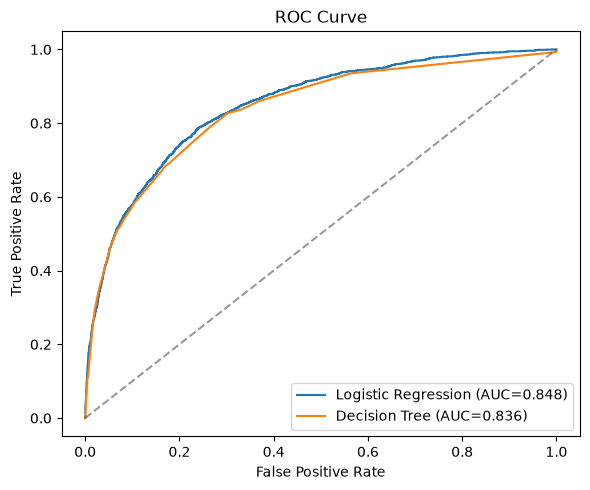

In [145]:
# create the ROC curve plot
plt.figure(figsize=(6, 5))
for name, y_proba in [("Logistic Regression", y_proba_log), ("Decision Tree", y_proba_tree)]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig("fig2.png")
plt.show()


There is no significant difference between the two methods: AUC = 0.848 for Logistic Regression and 0.836 for Decision Tree.  
Logistic Regression is chosen as the primary model because it performs slightly better on every metric here (higher AUC, higher recall, fewer False Negatives, fewer False Positives), and its coefficients are directly interpretable, which matters for regulatory review in a credit risk setting.  
The Decision Tree is included as a non-linear comparison, to check whether allowing the model to capture non-linear relationships would meaningfully improve performance; since it does not, the simpler and more interpretable model is preferred.

## 6. Core Analysis: Translating False Negatives into Financial Loss

We assume average Exposure at Default (EAD) per customer = \$10,000, Loss Given Default (LGD) = 60% i.e. the bank recovers 40% of the exposure on average

$$\text{Loss per FN} = EAD \times LGD$$

In [146]:
EAD = 10000
LGD = 0.60
loss_per_fn = EAD * LGD

print("Financial loss from False Negatives (assuming EAD=$10,000, LGD=60%)")
print("=" * 60)
for name, cm in [("Logistic Regression", cm_log), ("Decision Tree", cm_tree)]:
    tn, fp, fn, tp = cm.ravel()
    total_loss = fn * loss_per_fn
    print(f"{name}: {fn} missed defaulters (FN) -> estimated capital loss = ${total_loss:,.0f}")


Financial loss from False Negatives (assuming EAD=$10,000, LGD=60%)
Logistic Regression: 546 missed defaulters (FN) -> estimated capital loss = $3,276,000
Decision Tree: 608 missed defaulters (FN) -> estimated capital loss = $3,648,000


Even though Logistic Regression achieves a recall of 72.4% on the default class, it still misses 546 true defaulters in the test set.  
Under this exposure assumption, that translates into roughly $3.3M in potential losses on this test set alone - which explains why we often willing to tolerate more False Positives in exchange for fewer False Negatives.

## 7. Threshold Tuning and Cost Optimization


We assume each False Positive - a good customer wrongly flagged as risky, losing the bank interest income from a declined loan - costs \$500.  
Using this, we scan across classification thresholds for the Logistic Regression model to find the threshold that minimizes total cost.  

-  A lower threshold is a looser bar for flagging someone as a defaulter - it catches more true defaulters (lower FN) but also flags more good customers by mistake (higher FP)
- A higher threshold (e.g. 0.7) is a stricter bar - fewer false alarms (lower FP), but more missed defaulters (higher FN)

In [150]:
FP_cost = 500

thresholds = np.arange(0.05, 0.95, 0.02) # thresholds to test, from 0.05 to 0.93 in steps of 0.02
results = []
for t in thresholds:
    pred = (y_proba_val >= t).astype(int)
    cm = confusion_matrix(y_val, pred)
    tn, fp, fn, tp = cm.ravel()
    total_cost = fn * loss_per_fn + fp * FP_cost # total cost = cost of FN + opportunity cost of FP
    results.append((t, fn, fp, total_cost))

res_df = pd.DataFrame(results, columns=["threshold", "FN", "FP", "total_cost"]) # collect all thresholds and their costs into a table
best_row = res_df.loc[res_df["total_cost"].idxmin()] # find the threshold that minimizes total cost

print("Lowest total-cost point:")
print(best_row)


Lowest total-cost point:
threshold           0.51
FN                500.00
FP               5035.00
total_cost    5517500.00
Name: 23, dtype: float64


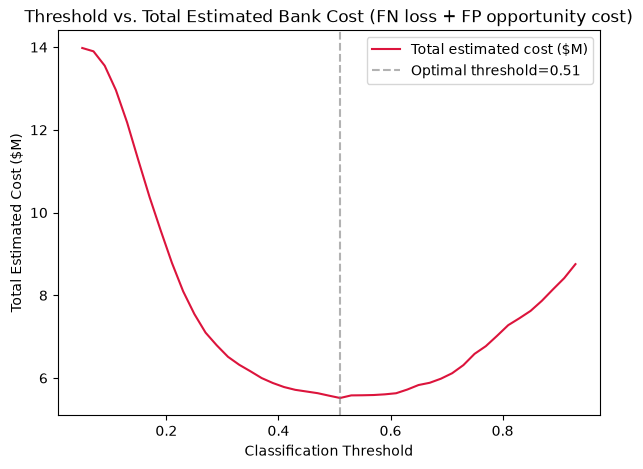

In [154]:
fig, ax1 = plt.subplots(figsize=(7, 5))
ax1.plot(res_df["threshold"], res_df["total_cost"] / 1e6, color="crimson", label="Total estimated cost ($M)")
ax1.axvline(best_row["threshold"], color="grey", linestyle="--", alpha=0.6,
            label=f"Optimal threshold={best_row['threshold']:.2f}")
ax1.set_xlabel("Classification Threshold")
ax1.set_ylabel("Total Estimated Cost ($M)")
ax1.set_title("Threshold vs. Total Estimated Bank Cost (FN loss + FP opportunity cost)")
ax1.legend()
plt.show()


The cost curve is U-shaped - a threshold too low drives up False Positives and opportunity cost, while a threshold too high drives up False Negatives and capital loss.  
The optimal threshold lands at 0.51, close to but not exactly the default 0.5.

## 8. Conclusion 

Logistic Regression is the preferred model. 
It has a slightly higher AUC (0.848 vs. 0.836) than the Decision Tree, and its coefficients are directly interpretable, which matters for regulatory review.

The recommended threshold of 0.51 should not be treated as fixed. It depends on the cost assumptions used. A bank would need its own loss data to calibrate these more precisely.

limitations: the model's probabilities are not true calibrated PDs, since `class_weight="balanced"` adjusts them for class imbalance, and these results are based on a single data split rather than cross-validation.  
A more complex model such as Random Forest or XGBoost could improve AUC, but at some cost to interpretability.